# Quarterly recommendation splits and a popularity baseline

Run `scripts/download_data.py`, then `scripts/make_splits.py` once before this notebook.
We learn from earlier **history → next-quarter outcomes** tasks, then predict the next quarter.
Initial training tasks cover 2003–2006, validation 2007–2010, and test 2011–2015; pre-2003 reviews remain history.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from remy.splits import RollingSplits, SPLIT_DIR
from remy.model.popularity import Popularity

splits = RollingSplits()
split = "val"  # Use "test" only after choosing and fixing model settings.
splits.windows.groupby("split", sort=False)[
    ["outcome_reviews", "positive_reviews", "positive_users"]
].sum().rename(columns={"positive_users": "positive_user_quarters"})

,outcome_reviews,positive_reviews,positive_user_quarters
split,,,
train,138126,106422,19880
val,377717,279537,61814
test,134059,100846,29079


## Get training data and evaluation data

`splits.training_quarters("2007-01-01")` returns the 16 completed training tasks from 2003–2006. For each task, build features from its `history` and labels from its `outcomes`.
`splits.evaluation_quarters("val")` returns the 16 held-out tasks from 2007–2010. Fit using only the past at each task's `start`, then score against its `outcomes`. Both return ordinary lists: `quarters[0]` gets the first task.

Popularity counts past reviews directly, so it ignores `training_quarters`; we pass them below to illustrate the shared model interface. Available recipes without reviews get score zero, and ties are broken by recipe ID.

## Score, then roll forward

Positives are 5-star reviews in the following quarter, from users with at least three prior reviews of **any** rating, on available, previously unseen recipes. Users with no positive that quarter receive no ranking score.
We compute **full-ranking NDCG** (no cutoff), plus hit rate and recall at 10 and 100; average over users within each quarter, then over quarters equally.

This small calculation is specific to Popularity, not the project's shared evaluator. Everyone shares its global ordering, so we find each positive's exact rank by subtracting already-seen recipes ahead of it; this avoids constructing thousands of full catalog lists.

In [2]:
def evaluate_popularity(model, quarter):
    """Full NDCG, HR@k and Recall@k from exact ranks in Popularity's ordering."""
    positives = quarter.outcomes[quarter.outcomes["rating"] == 5]
    global_rank = {recipe: rank for rank, recipe in enumerate(model.ranking_, start=1)}
    scores = []
    for user_id, rows in positives.groupby("user_id"):
        relevant = set(rows["recipe_id"])
        ranks = np.array([global_rank[recipe] for recipe in relevant])
        seen = model.seen_.get(user_id, set())
        seen_ranks = sorted(global_rank[recipe] for recipe in seen if recipe in global_rank)
        # Remove the number of already-seen recipes ranked above each positive.
        ranks = ranks - np.searchsorted(seen_ranks, ranks)
        dcg = (1 / np.log2(ranks + 1)).sum()
        ideal = (1 / np.log2(np.arange(2, len(relevant) + 2))).sum()
        metrics = {"NDCG": dcg / ideal}
        for k in (10, 100):
            hits = (ranks <= k).sum()
            metrics[f"HR@{k}"] = float(hits > 0)
            metrics[f"Recall@{k}"] = hits / len(relevant)
        scores.append(metrics)
    if not scores:
        raise ValueError(f"No scorable users at {quarter.start.date()}")
    result = {
        "start": quarter.start,
        "eligible_users": len(quarter.users),
        "scored_users": len(scores),
        "positives": len(positives),
    }
    result.update(pd.DataFrame(scores).mean().to_dict())
    return result

In [3]:
rows = []
for quarter in splits.evaluation_quarters(split):
    model = Popularity()  # Fresh fit each quarter; keep the settings fixed.
    model.fit(
        quarter.history,
        recipes=quarter.recipes,
        training_quarters=splits.training_quarters(quarter.start),
    )
    # Current outcomes are used only for scoring, after the fit.
    rows.append(evaluate_popularity(model, quarter))

results = pd.DataFrame(rows)
results.to_csv(SPLIT_DIR / f"popularity_{split}.csv", index=False)
results[["NDCG", "HR@10", "HR@100", "Recall@10", "Recall@100"]].mean().to_frame("Mean across quarters").round(4)

,Mean across quarters
NDCG,0.1251
HR@10,0.0398
HR@100,0.1604
Recall@10,0.0157
Recall@100,0.0703


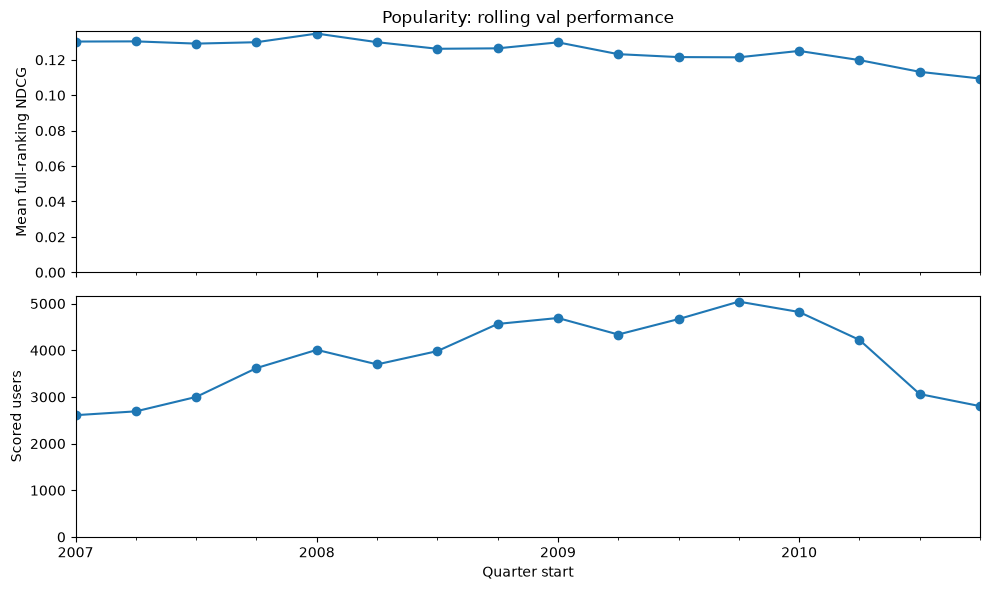

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
results.plot(x="start", y="NDCG", marker="o", legend=False, ax=axes[0])
axes[0].set(title=f"Popularity: rolling {split} performance", ylabel="Mean full-ranking NDCG")
axes[0].set_ylim(bottom=0)
results.plot(x="start", y="scored_users", marker="o", legend=False, ax=axes[1])
axes[1].set(ylabel="Scored users", xlabel="Quarter start")
axes[1].set_ylim(bottom=0)
fig.tight_layout()
plt.show()

The all-time ranking includes winter comfort foods (pot roast, chicken pot pie, potato soup) and some Christmas-tagged baking recipes, so it plausibly matches winter demand better than spring/summer demand. The first-quarter increases are consistent with that explanation, but do not establish the cause.

These scores describe active, eligible users, not every visitor; the second chart shows how that population changes. Below are the most-reviewed recipes at the **last checkpoint**, before each user's seen recipes are removed.

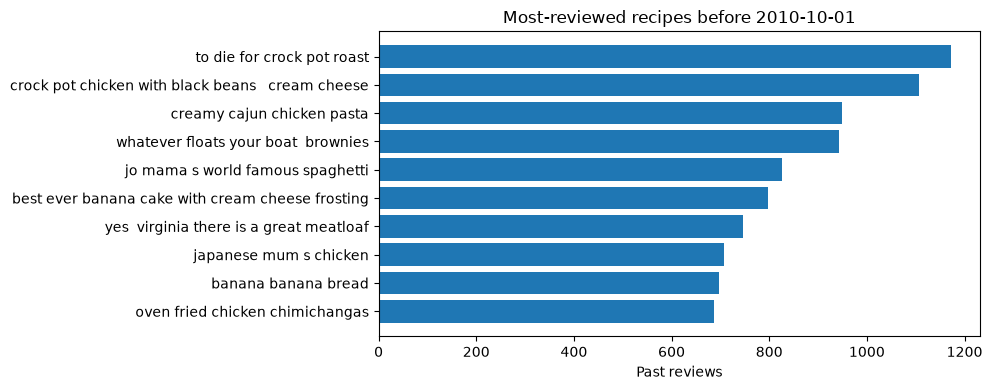

In [5]:
top = model.scores_.head(10).sort_values()
names = quarter.recipes.set_index("id")["name"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(names.reindex(top.index), top.values)
ax.set(title=f"Most-reviewed recipes before {quarter.start.date()}", xlabel="Past reviews")
fig.tight_layout()
plt.show()